# Basic demonstration of fUSi GLM analysis

To-do:Description of GLM

In [3]:
%load_ext autoreload
%autoreload 2

import os
import re
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
from gui import *
import image_utils
from pathlib import Path
from IPython.display import HTML, Video
from SessionLoader import SessionLoader

# import nilearn as nl
from nilearn import image
from nilearn.glm.first_level import make_first_level_design_matrix
from nilearn.plotting import plot_design_matrix

import nibabel as nib


# Load path and NIFTI data

In [32]:
#################################################################
#      Define data paths and choose output path location        #
#################################################################

save_output_on_local = True
base_path = '/Volumes/UCLA_collaboration/'
session_run = '2024-06-13/UCLA_006/run-09/'

# define output path to save data, plots, and videos (default: /fUSI_corrected)
if save_output_on_local:
    output_path = Path.home() / "Downloads" / "Data" / session_run  # save to user defined location e.g. (/Downloads folder)
else:
    # default to /fUSI_corrected within acqusition sequence in base_path (ses.sequence_data_path)
    output_path = None

#################################################################
#          Loading paths and choose acquisition sequence        #
#################################################################

# Find path using sessionLoader
ses = SessionLoader(base_path + session_run, sequence=None, output_path=output_path)
if ses.sequence_folders is not None:
    ses.load_acquisition_directories( sequence_index=0 ) # switch between sequences if there are multiple (default: 0)

#################################################################
#                          Loading NIFTI                        #
#################################################################

# apply registration
apply_image_registration = True
if apply_image_registration:
    # make sure process_fUSI_motion_correction.ipynb is run before this cell
    # registered_pd.nii.gz contains registered images with out-of-plane frames discarded
    filename = 'registered_pd.nii.gz' 
    extra = pd.read_csv(ses.output_path / 'transform_extra.csv') # load extra transformation data
else:
    filename = 'original.nii.gz' 
fusi_data = ses.load_nifti(path_name=ses.output_path, filename=filename)
nifti_data = nib.load(ses.output_path / filename)
ses.probe_events

Selected sequence in the acquisitions path:
--> 0. seq-RF_full_apert_5000000Hz_5a_3c_2rp_10Dmin_40Dmax_3el_TGC0ini_50end_8000Tdur_-1Gain_3AFE_200loops

Loaded directories:

 - log_file_path:       	/Volumes/UCLA_collaboration/2024-06-13/UCLA_006/run-09/logs/task_1.log
 - task_event_file_path:  	/Volumes/UCLA_collaboration/2024-06-13/UCLA_006/run-09/streams/task_1-event_stream.h5
 - probe_event_file_path: 	/Volumes/UCLA_collaboration/2024-06-13/UCLA_006/run-09/streams/probe_1-event_stream.h5
 - sequence_data_path:  	/Volumes/UCLA_collaboration/2024-06-13/UCLA_006/run-09/acquisitions/seq-RF_full_apert_5000000Hz_5a_3c_2rp_10Dmin_40Dmax_3el_TGC0ini_50end_8000Tdur_-1Gain_3AFE_200loops
 - raw_data_path:       	/Volumes/UCLA_collaboration/2024-06-13/UCLA_006/run-09/acquisitions/seq-RF_full_apert_5000000Hz_5a_3c_2rp_10Dmin_40Dmax_3el_TGC0ini_50end_8000Tdur_-1Gain_3AFE_200loops/raw_frame_data
 - beamformed_path:     	/Volumes/UCLA_collaboration/2024-06-13/UCLA_006/run-09/acquisitions/seq-RF_ful

,Event,raw_file_name,acquisition_idx,time_stamp,fusi_file_name,full_path,out_of_plane_labels
index,,,,,,,
0,ensemble_saved,ensemble_2024-06-13T20-32-17-674690.h5,0,3.717761,ensemble_2024-06-13T20-32-17-674690-pixel_size...,/Volumes/UCLA_collaboration/2024-06-13/UCLA_00...,0
1,ensemble_saved,ensemble_2024-06-13T20-32-19-886605.h5,1,5.982721,ensemble_2024-06-13T20-32-19-886605-pixel_size...,/Volumes/UCLA_collaboration/2024-06-13/UCLA_00...,0
2,ensemble_saved,ensemble_2024-06-13T20-32-21-780620.h5,2,7.839267,ensemble_2024-06-13T20-32-21-780620-pixel_size...,/Volumes/UCLA_collaboration/2024-06-13/UCLA_00...,0
3,ensemble_saved,ensemble_2024-06-13T20-32-23-635804.h5,3,9.686882,ensemble_2024-06-13T20-32-23-635804-pixel_size...,/Volumes/UCLA_collaboration/2024-06-13/UCLA_00...,0
4,ensemble_saved,ensemble_2024-06-13T20-32-25-498507.h5,4,11.556757,ensemble_2024-06-13T20-32-25-498507-pixel_size...,/Volumes/UCLA_collaboration/2024-06-13/UCLA_00...,0
...,...,...,...,...,...,...,...
97,ensemble_saved,ensemble_2024-06-13T20-35-21-367155.h5,97,187.459012,ensemble_2024-06-13T20-35-21-367155-pixel_size...,/Volumes/UCLA_collaboration/2024-06-13/UCLA_00...,0
98,ensemble_saved,ensemble_2024-06-13T20-35-23-283368.h5,98,189.521969,ensemble_2024-06-13T20-35-23-283368-pixel_size...,/Volumes/UCLA_collaboration/2024-06-13/UCLA_00...,0
99,ensemble_saved,ensemble_2024-06-13T20-35-25-379937.h5,99,191.486055,ensemble_2024-06-13T20-35-25-379937-pixel_size...,/Volumes/UCLA_collaboration/2024-06-13/UCLA_00...,0


In [20]:
#################################################################
#                    process task events                        #
#################################################################
task_events = ses.extract_task_events(behavior_offset=0) # also self.events
task_events

,trial_type,onset,duration
0,left_hand_squeeze_rev,20.020258,29.905302
1,left_hand_squeeze,77.186806,29.905416
2,left_hand_squeeze_rev,130.803787,29.905403
3,left_hand_squeeze,186.222194,29.905508


In [13]:
#############################################################################
#              If needed: discard any out-of-plane images                   #
#############################################################################

study_sub_period = True

# out-of-plane frame indices
oop_labels = ses.probe_events['out_of_plane_labels']
oop_indices = np.where(np.array(oop_labels) < 0)[0]
in_plane_indices = np.where(np.array(oop_labels) == 0)[0]

# define which indices to select
selected_indices = in_plane_indices

print(f'Number of out-of-plane frames: {len(oop_indices)}/{len(oop_labels)} ({len(oop_indices)/len(oop_labels)*100:.2f}%)')

if study_sub_period:
# Sub-period of probe_events
    probe_events = ses.probe_events.iloc[selected_indices].reset_index(drop=True)


Number of out-of-plane frames: 1/102 (0.98%)


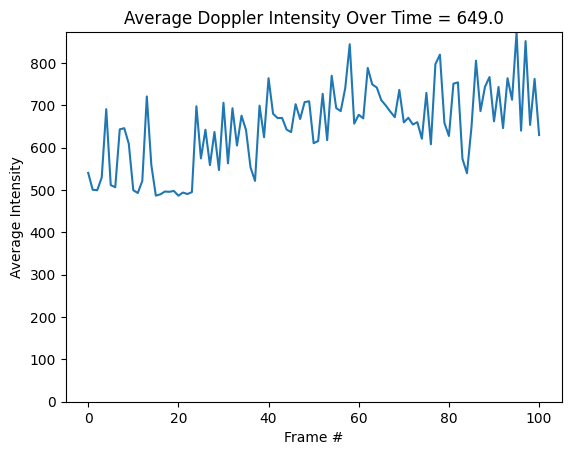

(array([540.42432231, 500.53880017, 499.41334422, 529.37492355,
        690.86602678, 511.54556489, 506.57022808, 643.21108168,
        645.95749809, 609.45618574, 499.51292149, 492.91067475,
        521.65361181, 720.97680463, 559.12819536, 486.7470296 ,
        489.74679848, 496.36576282, 495.76637893, 497.78607944,
        486.6121372 , 493.9526701 , 490.52441622, 495.01887993,
        697.81704708, 574.59170292, 642.36679285, 558.73088506,
        636.96880207, 547.07209673, 706.04402652, 562.92181659,
        693.01543694, 605.0814317 , 675.53291645, 641.75979802,
        553.40578655, 521.45578797, 699.27290706, 624.70441397,
        764.04421233, 680.00500251, 669.92660487, 670.12577136,
        642.71423301, 636.71291562, 702.64240909, 667.68282785,
        707.59124068, 709.55973718, 610.51597059, 615.61434255,
        727.19288967, 617.67322059, 769.80454929, 693.50412976,
        686.31266402, 740.25766267, 844.24845448, 656.77823117,
        677.72308401, 669.14865894, 788.

In [34]:
el = 0
doppler_intensity_per_frame = image_utils.plot_pd_intensity_over_time(fusi_data[:, el])

# Perform first level GLM analsysis

/var/folders/5l/sz09wmy52sg2qq3dt7_twxj40000gp/T/ipykernel_56946/1390675148.py:29: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



<Figure size 640x480 with 0 Axes>

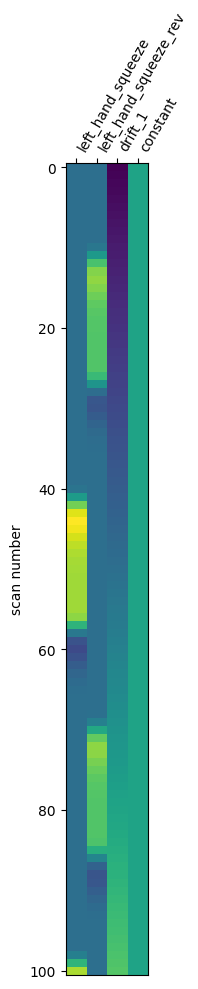

In [21]:
#######################################
#     Create design matrix for GLM    #
#######################################
# apply_image_registration=False
hrf_model = "glover"
if not apply_image_registration:
    design_matrix_name = 'yes_transform_design_mtx'
    design_matrix = make_first_level_design_matrix(
        probe_events['time_stamp'],
        task_events,
        drift_model="polynomial",
        drift_order=1,
        add_regs=extra[["translation_x", "translation_y", "rotation"]].to_numpy(),
        add_reg_names=["tx","ty","rot"],
        hrf_model=hrf_model,
    )
else:
    design_matrix_name = 'no_transform_design_mtx'
    design_matrix = make_first_level_design_matrix(
        probe_events['time_stamp'],
        task_events,
        drift_model="polynomial",
        drift_order=1,
        hrf_model=hrf_model,
    )

fig = plt.figure()
ax = plot_design_matrix(design_matrix)
fig.show()


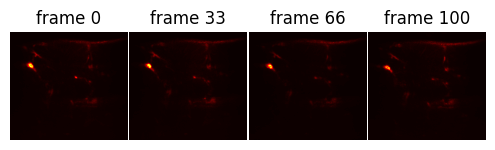

In [29]:
# santity check of some fusi images
image_utils.show_imgs(selected_fusi_data[:,el], frame_indices=np.linspace(0, selected_fusi_data.shape[3] - 1, 4, dtype=int))

In [30]:
# This cell creates an identity matrix of size equal to the number of columns in the design_matrix.
# It then constructs a dictionary named 'basic_contrasts' where each key is a column name from the design_matrix
# and the corresponding value is a row from the identity matrix. This effectively sets up basic contrasts
# for each experimental condition represented in the design_matrix.

contrast_matrix = np.eye(design_matrix.shape[1])
basic_contrasts = {
    column: contrast_matrix[i]
    for i, column in enumerate(design_matrix.columns)
}
for key in basic_contrasts.keys():
    print(f'{key:15}: {basic_contrasts[key]}')

left_hand_squeeze: [1. 0. 0. 0.]
left_hand_squeeze_rev: [0. 1. 0. 0.]
drift_1        : [0. 0. 1. 0.]
constant       : [0. 0. 0. 1.]


In [35]:
from nilearn.glm.first_level import FirstLevelModel

smoothing_fwhm=.5 #0 spatial smoothing in mm to apply to the data before computing GLM

# Initialize and fit the GLM model with specified parameters
print("Fitting a GLM")
fmri_glm = FirstLevelModel(minimize_memory=False,mask_img=False,smoothing_fwhm=smoothing_fwhm,standardize=True)
fmri_glm = fmri_glm.fit(nifti_data, design_matrices=design_matrix)

Fitting a GLM


# Perform first level GLM analsysis

Computing contrasts
	contrast id: left_hand_squeeze


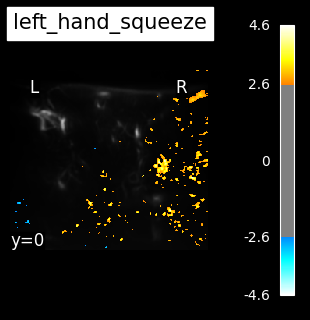

	contrast id: left_hand_squeeze_rev


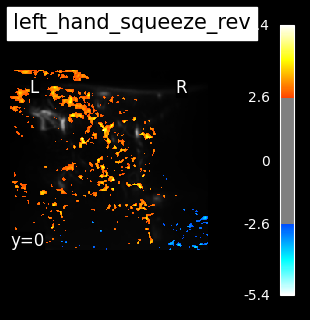

	contrast id: drift_1


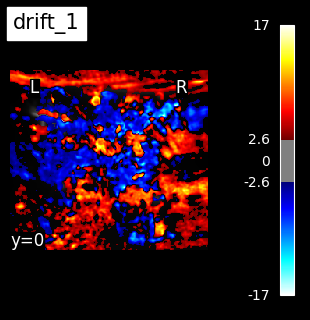

	contrast id: constant


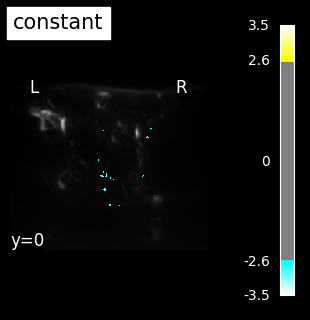

In [204]:
from nilearn import plotting
from nilearn.image import concat_imgs, mean_img, resample_img
import scipy.io
import os

print("Computing contrasts")

mean_image = mean_img(nifti_data)
base_path = "path/to/save/mat/files"  # Define the base path to save .mat files
os.makedirs(base_path, exist_ok=True)  # Create the directory if it doesn't exist

# Iterate on contrasts
for contrast_id, contrast_val in basic_contrasts.items():
    print(f"\tcontrast id: {contrast_id}")
    # compute the contrasts
    z_map = fmri_glm.compute_contrast(contrast_val, output_type="stat")
    # Save z_map in .mat format in the base_path folder
    scipy.io.savemat(os.path.join(base_path, f"{contrast_id}_z_map.mat"), {'z_map': z_map.get_fdata()})
    # plot the contrasts as soon as they're generated
    # the display is overlaid on the mean fMRI image
    # a threshold of 3.5 is used, more sophisticated choices are possible
    plotting.plot_stat_map(
        z_map,
        bg_img=mean_image,
        threshold=2.58,        
        cut_coords=[0],
        display_mode="y",        
        black_bg=True,        
        title=contrast_id,
    )
    plotting.show()

# Plot time series for ROI response and stimulus regressor

Identify ROIs using an automated clustering approach. Extract the time series for each ROI. Plot the time series and corresponding locations.



Processing contrast: left_hand_squeeze
Processing contrast: left_hand_squeeze_rev


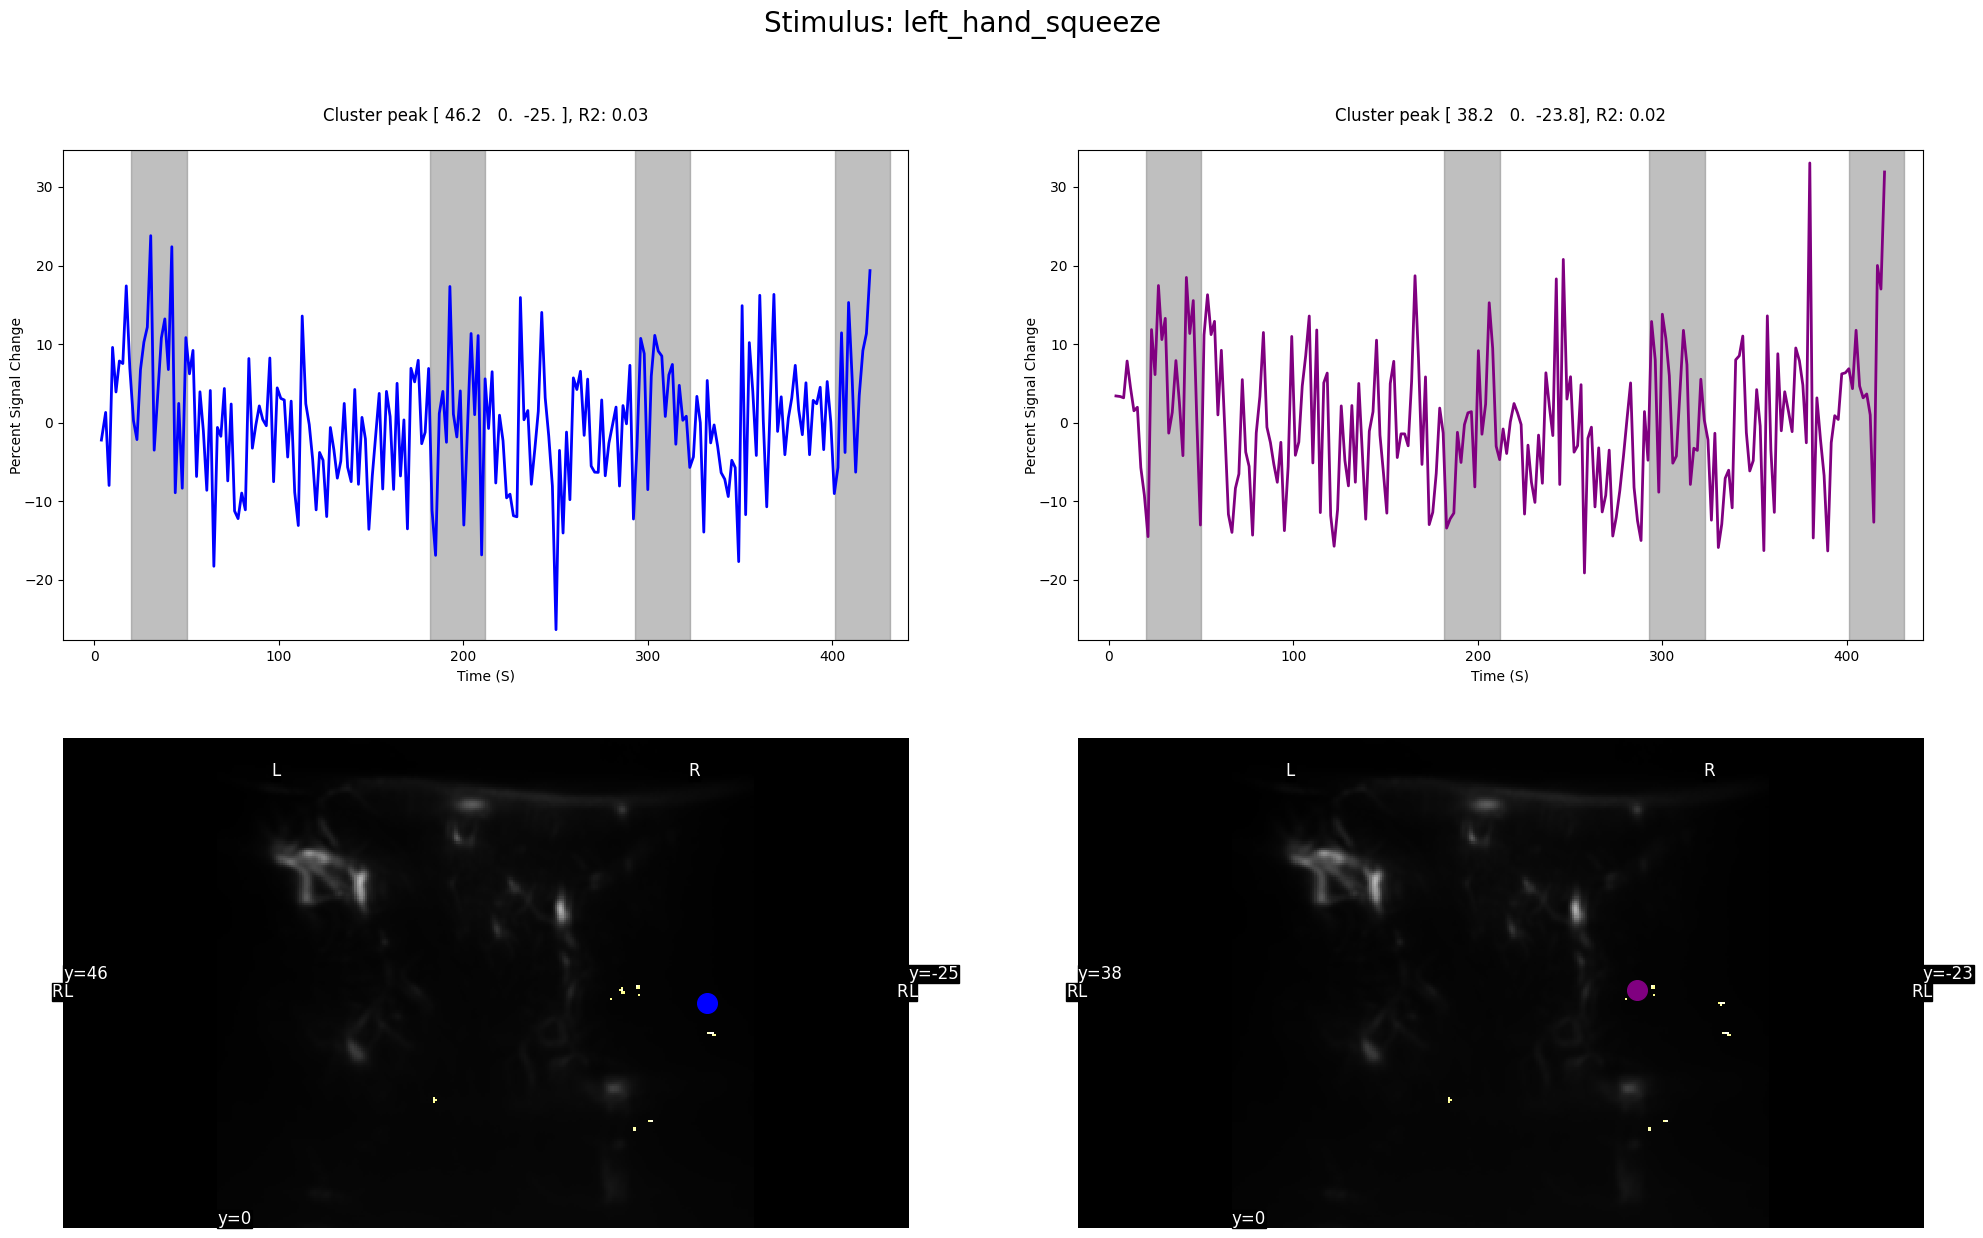

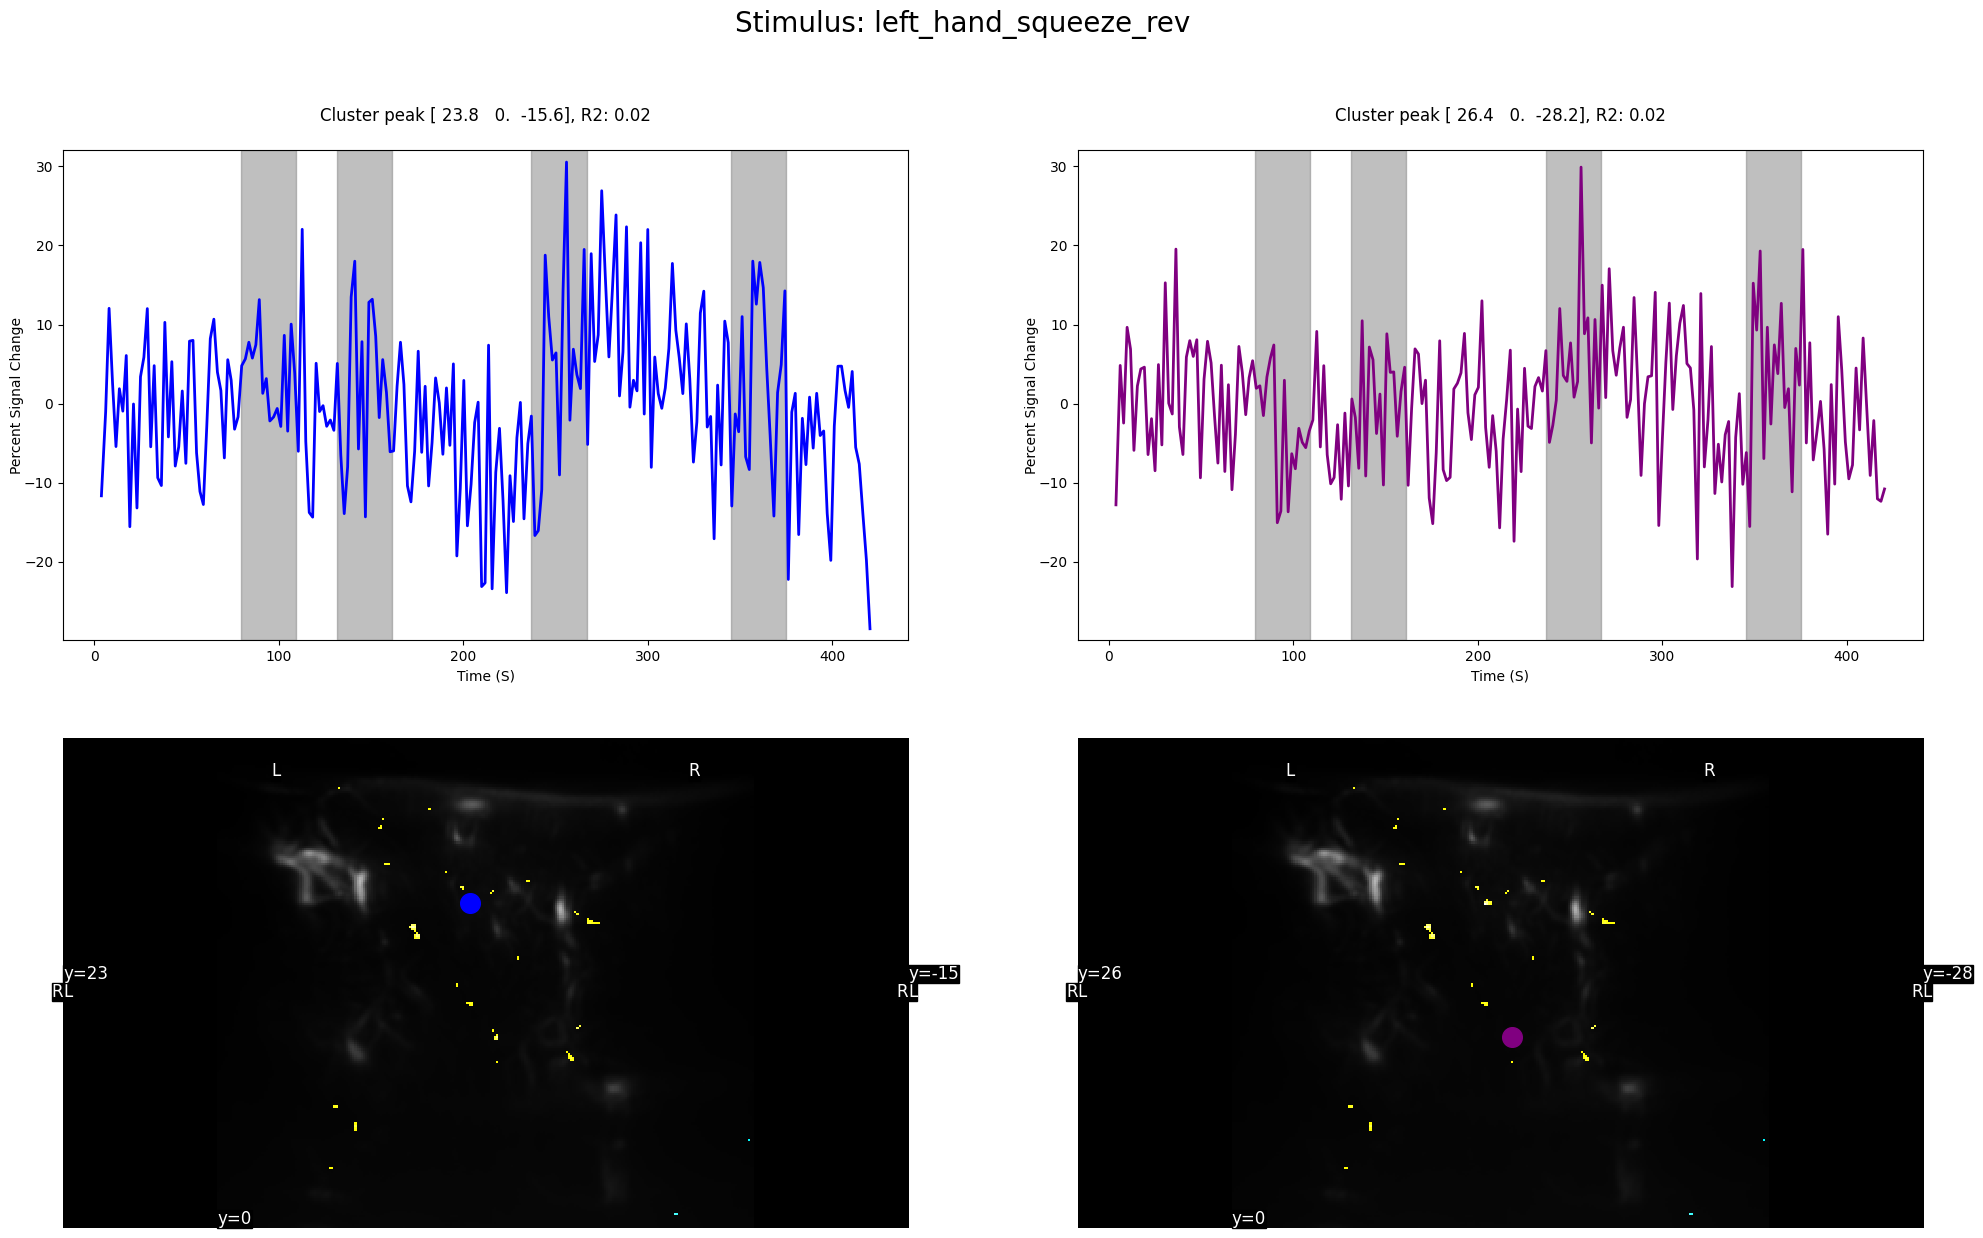

In [220]:
# from nilearn.maskers import NiftiSpheresMasker
# from nilearn.reporting import get_clusters_table
# import numpy as np

# behavior_offset = 0 # in seconds
# stat_threshold = 1
# num_locations = 2  # How many ROIs to visualize. An additional random ROI will be added

# # Find ROIs by identifying the locations that show a significant response to the stimulus
# mean_image = mean_img(nifti_data)

# # Loop over all conditions in basic_contrasts
# for contrast_id, contrast_val in basic_contrasts.items():
#     if contrast_id not in ['drift_1', 'constant','tx','ty','rot']:
#         print(f"Processing contrast: {contrast_id}")
#         z_map = fmri_glm.compute_contrast(contrast_val, output_type="stat")
#         table = get_clusters_table(z_map, stat_threshold=stat_threshold, cluster_threshold=20)
#         table.set_index("Cluster ID", drop=True)

#         if not table.empty and len(table) >= num_locations:
#             # get the num_locations largest clusters' max x, y, and z coordinates
#             coords = table.loc[range(0, num_locations), ["X", "Y", "Z"]].values
#             # coords = np.vstack([coords, [10.45000061, 0., 18.40000045]])

#             # Now use the ROIs to extract the time series 
#             masker = NiftiSpheresMasker(
#                 coords,
#                 radius=0.1,  # specifies the size of the spherical region around each given coordinate from which the signal will be extracted
#                 detrend=True,
#                 standardize="psc",  # zscore psc
#                 t_r=2.58,
#                 memory_level=1,
#                 verbose=0,
#             )
#             real_timeseries = masker.fit_transform(nifti_data)
#             predicted_timeseries = np.tile(design_matrix[contrast_id].values, (real_timeseries.shape[1], 1)).T

#             from sklearn.metrics import r2_score

#             # Calculate the R-squared value for each ROI
#             r_squared_values = []
#             for i in range(real_timeseries.shape[1]):
#                 r_squared = r2_score(real_timeseries[:, i], predicted_timeseries[:, i])
#                 r_squared_values.append(r_squared)
            
#             # Plotting the time series for each ROI and the corresponding location of each ROI
#             colors = ["blue", "purple", "magenta", "olive", "teal"]
#             N = real_timeseries.shape[-1]
#             fig1, axs1 = plt.subplots(2, N)
#             fig1.suptitle(f"Stimulus: {contrast_id}", fontsize=20)  # Set the title of the figure with a bigger font size
#             # get plot limits, common across all axis
#             mx = real_timeseries.max() + 0.05 * real_timeseries.max()
#             mn = real_timeseries.min() + 0.05 * real_timeseries.min()

#             for i in range(N):
#                 # plotting time series
#                 axs1[0, i].set_title(f"Cluster peak {coords[i].round(1)}, R2: {r_squared_values[i]:.2f}\n")
#                 if masker.standardize != "psc":
#                     axs1[0, i].plot(probe_events['time_stamp'], predicted_timeseries[:, i], c="k", ls="--", lw=1)

#                 axs1[0, i].plot(probe_events['time_stamp'], real_timeseries[:, i], c=colors[i], lw=2)

#                 axs1[0, i].set_xlabel("Time (S)")

#                 if masker.standardize == "psc":
#                     axs1[0, i].set_ylabel('Percent Signal Change', labelpad=0)
#                 else:
#                     axs1[0, i].set_ylabel("Signal intensity", labelpad=0)

#                 # plotting image below the time series
#                 for index, row in task_events.iterrows():
#                     if row['trial_type'] == contrast_id and row['onset'] > probe_events['time_stamp'].iloc[0]:
#                         axs1[0, i].axvspan(row['onset'] + behavior_offset, row['onset'] + row['duration'] + behavior_offset, color='gray', alpha=0.5)
#                 roi_img = plotting.plot_stat_map(
#                     z_map,
#                     cut_coords=coords[i],
#                     threshold=4,
#                     figure=fig1,
#                     axes=axs1[1, i],
#                     display_mode="y",
#                     colorbar=False,
#                     bg_img=mean_image,
#                 )

#                 axs1[0, i].set_ylim(mn, mx)
#                 roi_img.add_markers([coords[i]], colors[i], 200)
#             fig1.set_size_inches(24, 14)
#             fig1.savefig(output_path / f"{design_matrix_name}"/ f"{contrast_id}_time_series.png", dpi=400)
#         else:
#             print(f"No valid clusters found for {contrast_id} that meet the criteria.")


In [226]:
# from nilearn.maskers import NiftiSpheresMasker
# from nilearn.reporting import get_clusters_table
# import numpy as np
# import matplotlib.pyplot as plt
# from nilearn import plotting

# stat_threshold = 1
# num_locations = 2  # How many ROIs to visualize. An additional random ROI will be added

# # Find ROIs by identifying the locations that show a significant response to the stimulus
# mean_image = mean_img(nifti_data)

# # Loop over all conditions in basic_contrasts
# for contrast_id, contrast_val in basic_contrasts.items():
#     if contrast_id not in ['drift_1', 'constant', 'tx', 'ty', 'rot']:
#         print(f"Processing contrast: {contrast_id}")
#         z_map = fmri_glm.compute_contrast(contrast_val, output_type="stat")
#         table = get_clusters_table(z_map, stat_threshold=stat_threshold, cluster_threshold=20)
        
#         if not table.empty and len(table) >= num_locations:
#             coords = table.loc[range(0, num_locations), ["X", "Y", "Z"]].values
#             # coords = np.vstack([coords, [10.45000061, 0., 18.40000045]])

#             masker = NiftiSpheresMasker(
#                 coords,
#                 radius=3,
#                 detrend=True,
#                 standardize="zscore",
#                 t_r=2.58,
#                 memory_level=1,
#                 verbose=0,
#                 allow_overlap=True
#             )
#             real_timeseries = masker.fit_transform(nifti_data)
#             predicted_timeseries = masker.fit_transform(fmri_glm.predicted[0])

#             # Compute predicted time series for each contrast
#             contrast_predicted_timeseries = {}
#             for key in basic_contrasts.keys():
#                 contrast_effect = fmri_glm.compute_contrast(basic_contrasts[key], output_type='effect_size')
#                 # Ensure the effect size image is correctly transformed into a time series
#                 contrast_predicted = masker.fit_transform(contrast_effect.slicer[:,:,:,0])  # Adjust slicing if necessary
#                 contrast_predicted_timeseries[key] = contrast_predicted
#                 # print(f"Shape of predicted time series for {key}: {contrast_predicted.shape}")  # Debugging line

#             # Plotting
#             colors = ["blue", "purple", "magenta", "olive", "teal"]
#             fig, axs = plt.subplots(2, len(coords), figsize=(24, 14))
#             fig.suptitle(f"Stimulus: {contrast_id}", fontsize=20)

#             for i, coord in enumerate(coords):
#                 # axs[0, i].plot(probe_events['time_stamp'], real_timeseries[:, i], label='Real', color=colors[i])
#                 axs[0, i].plot(probe_events['time_stamp'], predicted_timeseries[:, i], label='Predicted', color='black', linestyle='--')
                
#                 # Plot each contrast's predicted time series
#                 for key in contrast_predicted_timeseries:
#                     if contrast_predicted_timeseries[key].shape[0] == len(probe_events['time_stamp']):
#                         axs[0, i].plot(probe_events['time_stamp'], contrast_predicted_timeseries[key][:, i], label=f'Predicted {key}', linestyle=':')
#                     # else:
#                         # print(f"Dimension mismatch for {key}: {contrast_predicted_timeseries[key].shape}")

#                 axs[0, i].set_title(f"ROI at {coord.round(1)}")
#                 axs[0, i].set_xlabel("Time (s)")
#                 axs[0, i].set_ylabel("Signal")
#                 axs[0, i].legend()
#                 # Display the statistical map with a different display mode and without a colorbar
#                 roi_img = plotting.plot_stat_map(
#                     z_map,
#                     cut_coords=coords[i],
#                     threshold=4,
#                     figure=fig,
#                     axes=axs[1, i],
#                     display_mode="y",
#                     colorbar=False,
#                     bg_img=mean_image,
#                 )
#                 roi_img.add_markers([coords[i]], marker_color=colors[i], marker_size=200)

#                 # plotting image below the time series
#                 for index, row in task_events.iterrows():
#                     if row['trial_type'] == contrast_id and row['onset'] > probe_events['time_stamp'].iloc[0]:
#                         axs[0, i].axvspan(row['onset'] + behavior_offset, row['onset'] + row['duration'] + behavior_offset, color='gray', alpha=0.5)
#             fig.savefig(output_path / f"{design_matrix_name}"/ f"{contrast_id}_contrast_predicted.png", dpi=400)

#             plt.tight_layout()
#             plt.show()

Processing contrast: left_hand_squeeze
Processing contrast: left_hand_squeeze_rev


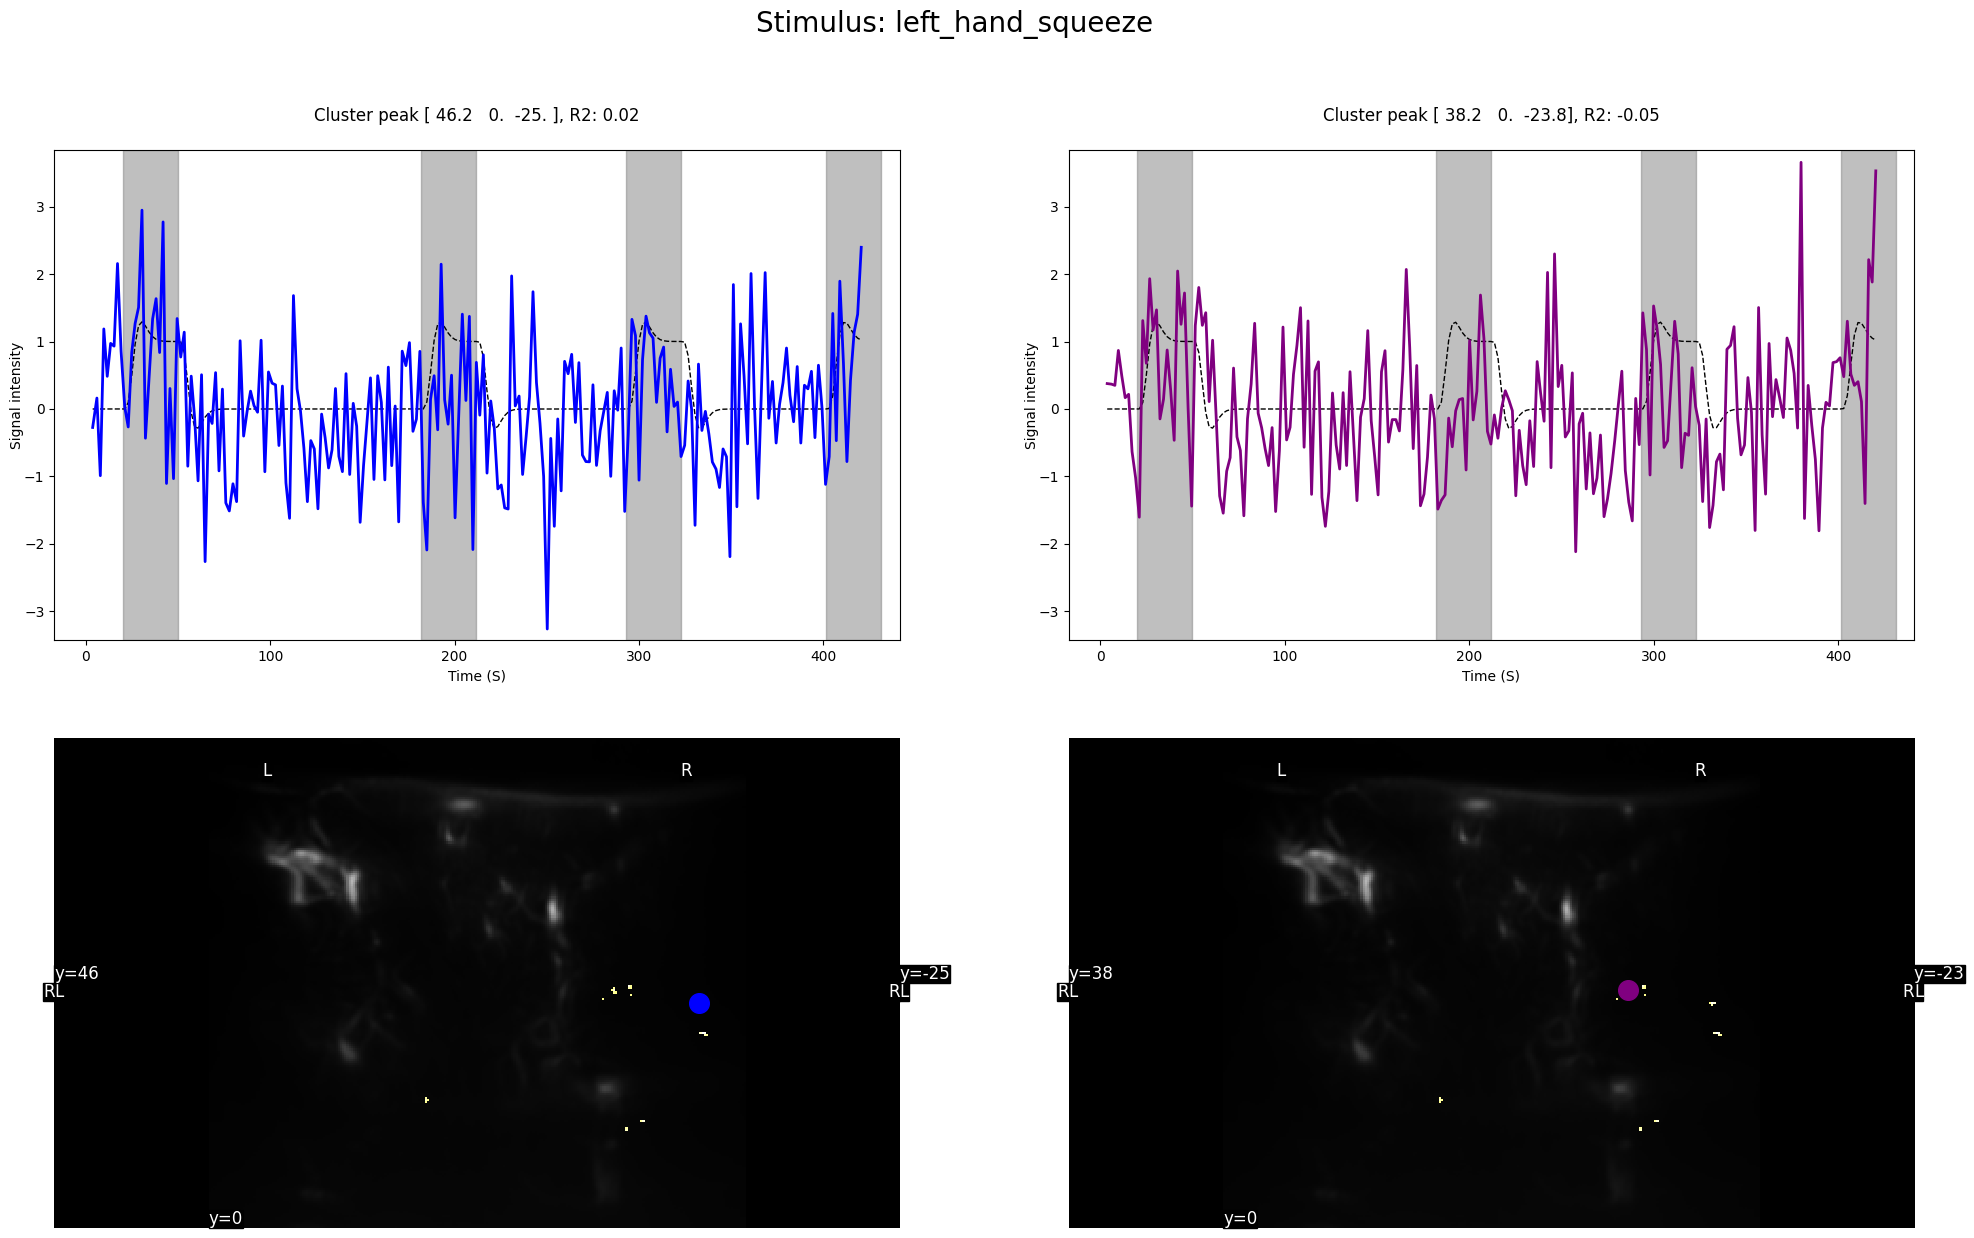

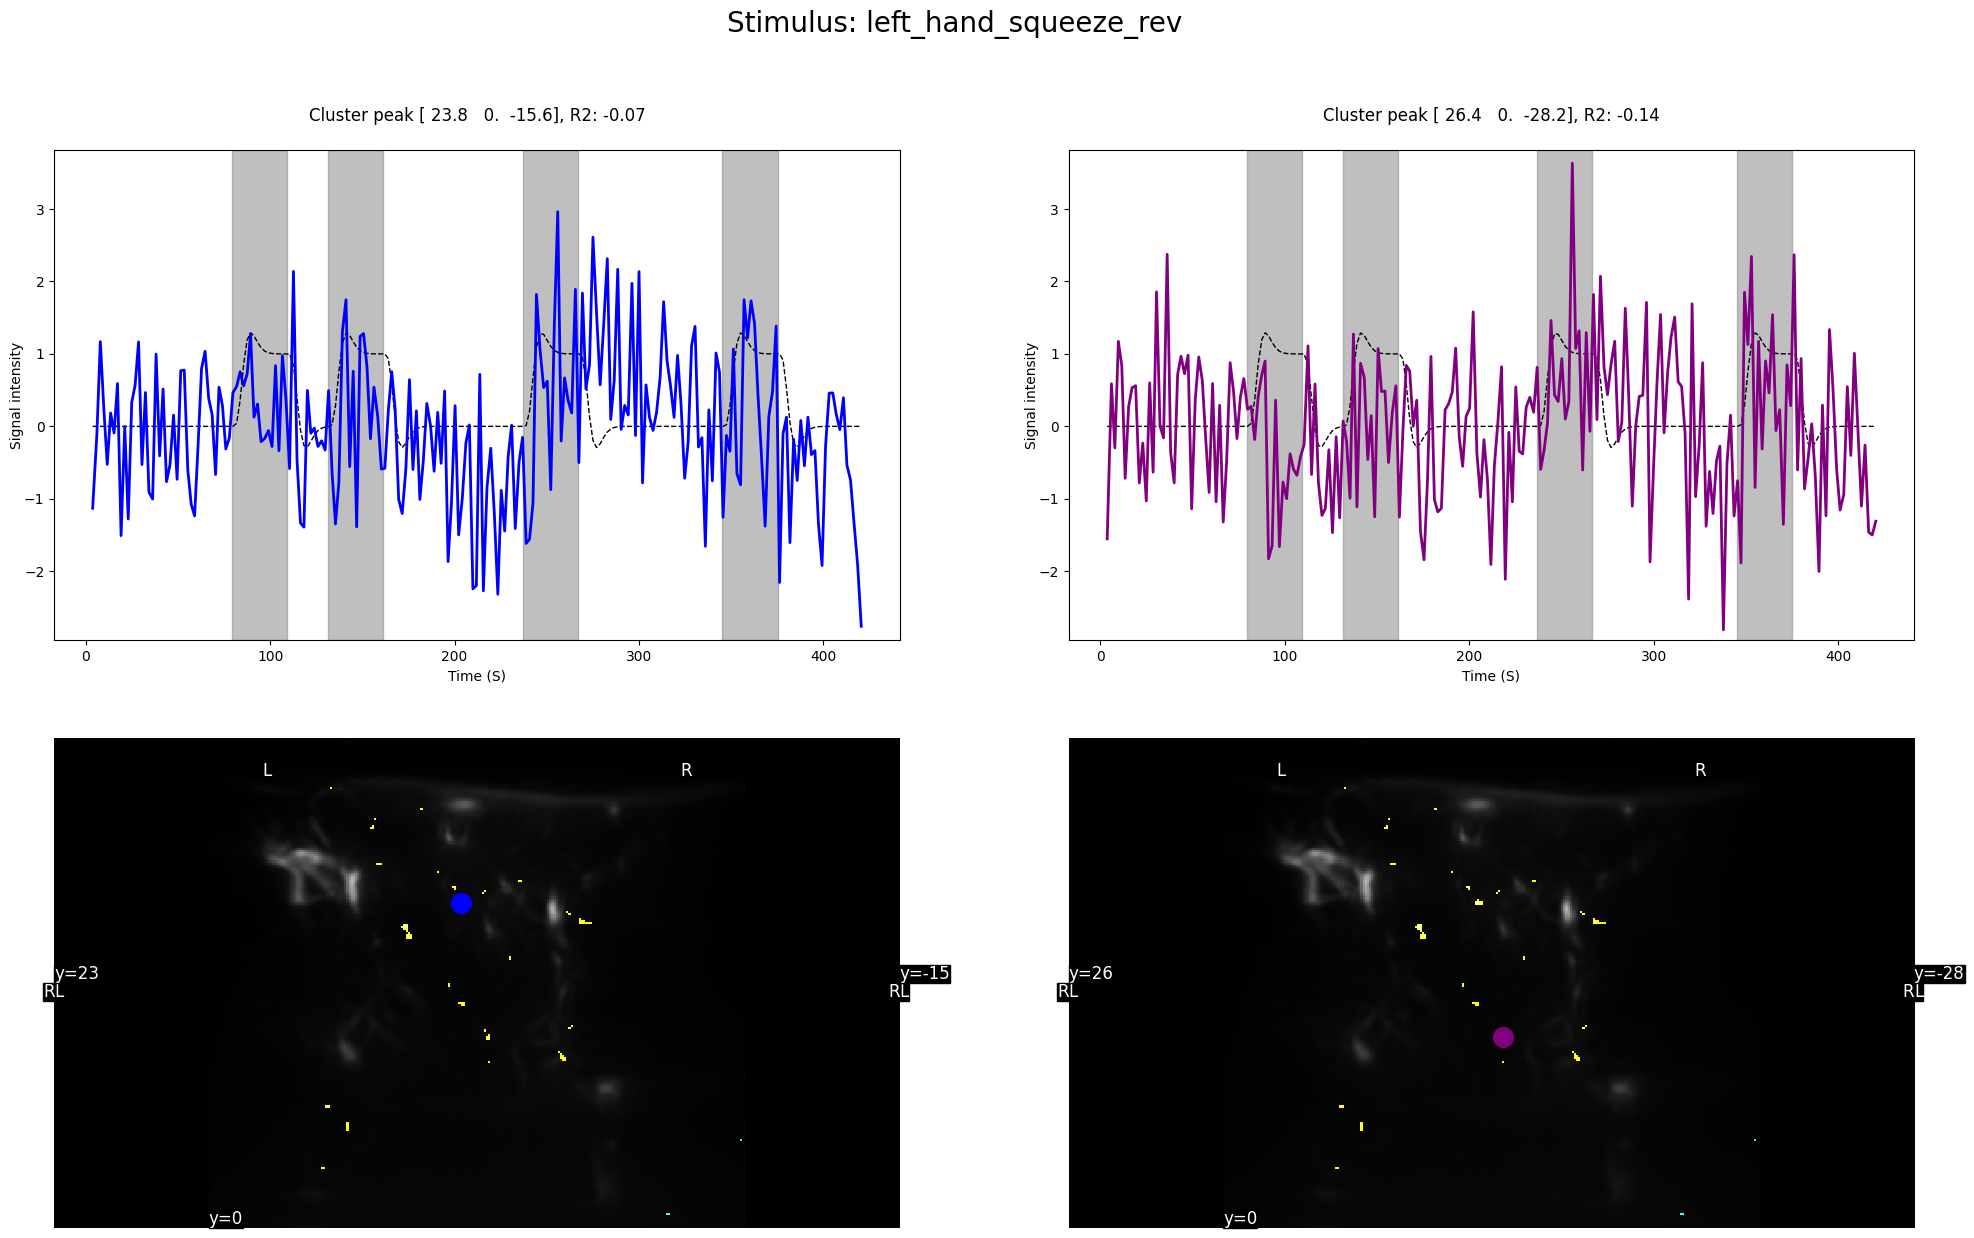

In [228]:
from nilearn.maskers import NiftiSpheresMasker
from nilearn.reporting import get_clusters_table
import numpy as np

stat_threshold = 1
num_locations = 2  # How many ROIs to visualize. An additional random ROI will be added

# Find ROIs by identifying the locations that show a significant response to the stimulus
mean_image = mean_img(nifti_data)

# Loop over all conditions in basic_contrasts
for contrast_id, contrast_val in basic_contrasts.items():
    if contrast_id not in ['drift_1', 'constant','tx','ty','rot']:
        print(f"Processing contrast: {contrast_id}")
        z_map = fmri_glm.compute_contrast(contrast_val, output_type="stat")
        table = get_clusters_table(z_map, stat_threshold=stat_threshold, cluster_threshold=20)
        table.set_index("Cluster ID", drop=True)

        if not table.empty and len(table) >= num_locations:
            # get the num_locations largest clusters' max x, y, and z coordinates
            coords = table.loc[range(0, num_locations), ["X", "Y", "Z"]].values

            # Now use the ROIs to extract the time series 
            masker = NiftiSpheresMasker(
                coords,
                radius=0.1,  # specifies the size of the spherical region around each given coordinate from which the signal will be extracted
                detrend=True,
                standardize="zscore",  # zscore psc
                t_r=3.5,
                memory_level=1,
                verbose=0,
            )
            real_timeseries = masker.fit_transform(nifti_data)
            predicted_timeseries = np.tile(design_matrix[contrast_id].values, (real_timeseries.shape[1], 1)).T

            from sklearn.metrics import r2_score

            # Calculate the R-squared value for each ROI
            r_squared_values = []
            for i in range(real_timeseries.shape[1]):
                r_squared = r2_score(real_timeseries[:, i], predicted_timeseries[:, i])
                r_squared_values.append(r_squared)
            
            # Plotting the time series for each ROI and the corresponding location of each ROI
            colors = ["blue", "purple", "magenta", "olive", "teal"]
            N = real_timeseries.shape[-1]
            fig1, axs1 = plt.subplots(2, N)
            fig1.suptitle(f"Stimulus: {contrast_id}", fontsize=20)  # Set the title of the figure with a bigger font size
            # get plot limits, common across all axis
            mx = real_timeseries.max() + 0.05 * real_timeseries.max()
            mn = real_timeseries.min() + 0.05 * real_timeseries.min()

            for i in range(N):
                # plotting time series
                axs1[0, i].set_title(f"Cluster peak {coords[i].round(1)}, R2: {r_squared_values[i]:.2f}\n")
                if masker.standardize != "psc":
                    axs1[0, i].plot(probe_events['time_stamp'], predicted_timeseries[:, i], c="k", ls="--", lw=1)

                axs1[0, i].plot(probe_events['time_stamp'], real_timeseries[:, i], c=colors[i], lw=2)

                axs1[0, i].set_xlabel("Time (S)")

                if masker.standardize == "psc":
                    axs1[0, i].set_ylabel('Percent Signal Change', labelpad=0)
                else:
                    axs1[0, i].set_ylabel("Signal intensity", labelpad=0)

                # plotting image below the time series
                for index, row in task_events.iterrows():
                    if row['trial_type'] == contrast_id and row['onset'] > probe_events['time_stamp'].iloc[0]:
                        axs1[0, i].axvspan(row['onset'] + behavior_offset, row['onset'] + row['duration'] + behavior_offset, color='gray', alpha=0.5)
                roi_img = plotting.plot_stat_map(
                    z_map,
                    cut_coords=coords[i],
                    threshold=4,
                    figure=fig1,
                    axes=axs1[1, i],
                    display_mode="y",
                    colorbar=False,
                    bg_img=mean_image,
                )

                axs1[0, i].set_ylim(mn, mx)
                roi_img.add_markers([coords[i]], colors[i], 200)
            fig1.set_size_inches(24, 14)
            fig1.savefig(output_path / f"{design_matrix_name}"/ f"{contrast_id}_time_series_and_contrast_predicted.png", dpi=400)

        else:
            print(f"No valid clusters found for {contrast_id} that meet the criteria.")